<a href="https://colab.research.google.com/github/fzunigaGH/Proyectos/blob/main/Proyecto_Predicci%C3%B3n_de_renuncia_de_clientes_(Churn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Predicción de renuncia de clientes (Churn)

## El Problema

El Churn es un indicador crítico que afecta directamente la salud financiera y la viabilidad del negocio a largo plazo de las empresas Telco debido a diversos factores.

* Por una parte, las empresas invierten gran cantidad de recursos en publicidad, comisiones de ventas. Además, generalmente subsidian equipos y/o instalaciones técnica. Si un cliente se va antes de recuperar esa inversión inicial, la empresa pierde dinero de forma neta.

* Cuando un cliente se marcha, la empresa no solo pierde la factura del mes actual, sino todo el flujo de ingresos proyectado que ese usuario generaría durante años.

* En Chile actualmente el sector de Telecomunicaciones es un mercado maduro y altamente competitivo. Al haber pocos "clientes nuevos" (personas que nunca han tenido un plan), el crecimiento de una compañía depende de quitarle clientes a la competencia, lo cual implica invertir no solo recuros económicos sino también en doblar los esfuerzos para mantener su market share.

* Una tasa de fuga inestable hace que sea muy difícil para la empresa planificar inversiones en infraestructura. Si no saben cuántos clientes tendrán en seis meses debido a una alta tasa de cancelación

En consecuencia conseguir un cliente nuevo es significativamente más caro que mantener a uno actual.

## Objetivo

El objetivo de este proyecto es identificar de manera anticipada a aquellos clientes que tienen una alta probabilidad de renunciar, implementando un modelo de clasificación (mediante técnicas avanzadas de aprendizaje automático para optimizar la precisión) que permita anticipar la implementación de acciones orientadas a prevenir la fuga de clientes.

## Diccionario de Datos

La base de datos a utilizar, cuenta con 12 atributos regresores más la etiqueta de clase, que son:

* **Call Failures:** Número de fallos de llamadas
* **omplaints:** Quejas (1) o ninguna queja (0)
* **Subscription Length:** Meses totales de suscripción
* **Charge Amount:** Importe del cargo, atributo ordinal (0: importe más bajo, 9: importe más
alto)
* **Seconds of Use:** Segundos totales de llamadas
* **Frequency of use:** Número total de llamadas
* **Frequency of SMS:** Número total de mensajes de texto
* **Distinct Called Numbers:** Número total de llamadas distintas
* **Age Group:** Grupo de edad, atributo ordinal (1: menor edad, 5: mayor edad)
* **Tariff Plan:** Plan de tarifa, binario (1: pago por uso, 2: contractual)
* **Status:** Estado, binario (1: activo, 2: inactivo)
* **Churn:** Renuncia, binario (1: cancelación, 0: no cancelación) - Etiqueta de clase
* **Customer Value:** El valor calculado del cliente

## Metodología

####1. Requerimientos previos.

1.1. Se procederá a importar las librerías necesarias para aplicar preprocesamiento de datos, visualización y creación de un modelo de red neuronal feedforward con Keras y Tensorflow.

1.2. A continuación se importará la base de datos **Customer Churn.csv** y se realizá el preprocesamiento de los datos.

###2. **Crhurn** v/s **Subscriprtion Length**

2.1. Se Analizará la distribución de “Subscription Length” para cada clase (Churn), describiendo si hay alguna incidencia de esta variable en la renuncia o no. Se ealizará una estandarización de las variables regresoras

###3. Definición de conjuntos Train y Test.
3.1. Se verificará la frecuencia de cada clase y, en caso de ser necesarios se realizará un balanceo de clase usando SMOTE.

3.2. A continuación el Dataset ya procesado será dividido en conjunto de entrenamiento y test, considerando para este último un 33% del Dataset.

###4. Modelo Machine Learning **RandomForest**
4.1. Se entrenará un modelos **RandomForest** con hiperparámetros por defecto.

4.2. Se presentará métrica F1-Score para ambas clases.

4.3. Se presentarán las características más importantes detectadas por el modelo **RandomForest**.

4.4. Se presentarán los 7 atributos o característicos más representativos.

###5. Modelo Red Neuronal.
5.1. Usando las carácterísicas encontradas anteriormente, se filtrará el conjunto de entrenamiento y entrena el modelo de red neuronal, definiendo:

5.2. Función de activación adecuada, tanto para la
capa oculta como para la capa de salida, la cantidad de neuronas a usar, la tasa de aprendizaje (learning_rate), y la cantidad de épocas deben ser ajustadas
manualmente.

**Nota 1:** Como optimizador, se utilizará el Descenso del Gradiente Estocástico.

**Nota 2:** Se busca establecer que la métrica AUC de la curva ROC sea mayor al 90% ajustando manualmente los hiper parámetro.


##1. Requerimientos previos

###1.1. Librerías y funciones requeridas

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

from imblearn.over_sampling import SMOTE


import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import SGD


In [ ]:
def calidad_datos(datos):
  tipos = pd.DataFrame(datos.dtypes, columns = ['tipo'])
  nan = pd.DataFrame(datos.isna().sum(), columns = ['nan'])
  nan_prop = pd.DataFrame(datos.isna().sum()/datos.shape[0]*100, columns = ['porcentaje_nan'])
  ceros = pd.DataFrame([datos.loc[datos[col] == 0, col].shape[0]  for col in datos.columns], \
                       columns = ['ceros'], index = datos.columns)
  ceros_prop = pd.DataFrame([datos.loc[datos[col] == 0, col].shape[0]/datos.shape[0]*100  for col in datos.columns],\
                       columns = ['porcentaje_ceros'], index = datos.columns)

  resumen = datos.describe(include = 'all').T
  resumen['IQR'] = resumen['75%'] - resumen['25%']
  resumen['lim_inf'] = resumen['25%'] - resumen['IQR']*1.5
  resumen['lim_sup'] = resumen['75%'] + resumen['IQR']*1.5

  resumen['atipicos'] = datos.apply(lambda x: sum(np.where((x < resumen['lim_inf'][x.name]) | (x > resumen['lim_sup'][x.name]), 1, 0)) \
                                    if x.name in resumen['lim_inf'].dropna().index else 0)

  return pd.concat([tipos, nan, nan_prop, ceros, ceros_prop, resumen], axis = 1).sort_values('tipo')

def graficos(calidad, datos, cols):
  num_cols = len(cols)
  num_rows = (num_cols + 2) // 3
  plt.figure(figsize = (15, 3 * num_rows))
  for n, i in enumerate(cols):
    plt.subplot(num_rows, 3, n+1)
    if calidad.loc[i, 'tipo'] == 'object':
      sns.countplot(y = datos[i], order = datos[i].value_counts().iloc[:16].index)
      plt.title(f'Frecuencias para {i}')
      plt.tight_layout()
    else:
      sns.distplot(datos[i])
      plt.title(f'Distribución para {i}')
      plt.tight_layout()

def no_atipicos(columna):
  q1 = columna.quantile(0.25)
  q3 = columna.quantile(0.75)
  rango_iq = q3 - q1
  lim_inf = q1 - 1.5*rango_iq
  lim_sup = q3 + 1.5*rango_iq
  condicion = (columna >= lim_inf) & (columna <= lim_sup) # & and en pandas, | or en pandas
  return condicion

def correlacion(datos, target, dicotomic = False):
  numeric_features = datos.select_dtypes(include=[np.number]).columns.tolist()
  for feature in numeric_features:
    dfi = datos.loc[:, [feature, target]].dropna()
    corr, _ = pearsonr(dfi[feature], dfi[target])
    if isinstance(corr, np.ndarray):
      print(f"Correlación de Pearson entre {feature} y {target}: {corr[0]:.2f}")
    else:
      print(f"Correlación de Pearson entre {feature} y {target}: {corr:.2f}")

  correlation_matrix_numeric = datos[numeric_features].corr()

  plt.rcParams.update({'font.size': 12})
  plt.figure(figsize = (4,8))
  sns.heatmap(correlation_matrix_numeric.loc[:, [target]].sort_values(target, ascending = False).iloc[1:], cmap = 'Reds', annot = True)

  categorical_features = datos.select_dtypes(include=[object]).columns.tolist()
  if dicotomic == True:
    for feature in categorical_features:
      target_modificado = datos[target].replace({1: 'Positiva', 0: 'Negativa'})
      chi2, p, _, _ = chi2_contingency(pd.crosstab(datos[feature], target_modificado))
      if p < 0.05:
        print(f"Chi-cuadrado entre {feature} y {target}: {chi2:.2f}, p-value: {p:.4f}. Hay relación entre las variables.")
      else:
        print(f"Chi-cuadrado entre {feature} y {target}: {chi2:.2f}, p-value: {p:.4f}. Las variables son independientes.")
  return numeric_features, categorical_features


def remove_outliers(df, column):# función remove_outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_desafio = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return  df_desafio

def identifica_outliers(df, column):# función identifica_outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
    sns.boxplot(df[column])
    plt.show()
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_SO = df[(df[column]< lower_bound) | (df[column] > upper_bound)]
    #print(f"\n\nA continuación se presentan los registros outliers\n")
    #sns.histplot(df_SO[column], bins= 20
    return df_SO

def df_sin_outliers(df, column): # función que retorna un DataFrame sin elementos outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_desafio = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_desafio

##1.2. Importe y Análisis Exploratorio de Datos

In [ ]:
df_inicial = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/06 - Modelos Avanzados/04 - Redes Neuronales (parte I)/Customer Churn.csv', sep = ',')

In [ ]:
df_inicial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

In [ ]:
df_inicial.head(10)

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0
5,11,0,38,1,3775,82,32,28,3,1,1,30,282.280,0
6,4,0,38,0,2360,39,285,18,3,1,1,30,1235.960,0
7,13,0,37,2,9115,121,144,43,3,1,1,30,945.440,0
8,7,0,38,0,13773,169,0,44,3,1,1,30,557.680,0
9,7,0,38,1,4515,83,2,25,3,1,1,30,191.920,0


In [ ]:
calidad_datos(df_inicial)

,tipo,nan,porcentaje_nan,ceros,porcentaje_ceros,count,mean,std,min,25%,50%,75%,max,IQR,lim_inf,lim_sup,atipicos
Call Failure,int64,0,0.0,702,22.285714,3150.0,7.627937,7.263886,0.0,1.00000,6.00,12.00000,36.00,11.0000,-15.50,28.50,47
Complains,int64,0,0.0,2909,92.349206,3150.0,0.076508,0.265851,0.0,0.00000,0.00,0.00000,1.00,0.0000,0.00,0.00,241
Subscription Length,int64,0,0.0,0,0.000000,3150.0,32.541905,8.573482,3.0,30.00000,35.00,38.00000,47.00,8.0000,18.00,50.00,282
Charge Amount,int64,0,0.0,1768,56.126984,3150.0,0.942857,1.521072,0.0,0.00000,0.00,1.00000,10.00,1.0000,-1.50,2.50,370
Seconds of Use,int64,0,0.0,154,4.888889,3150.0,4472.459683,4197.908687,0.0,1391.25000,2990.00,6478.25000,17090.00,5087.0000,-6239.25,14108.75,200
Frequency of use,int64,0,0.0,154,4.888889,3150.0,69.460635,57.413308,0.0,27.00000,54.00,95.00000,255.00,68.0000,-75.00,197.00,129
Frequency of SMS,int64,0,0.0,603,19.142857,3150.0,73.174921,112.237560,0.0,6.00000,21.00,87.00000,522.00,81.0000,-115.50,208.50,368
Distinct Called Numbers,int64,0,0.0,154,4.888889,3150.0,23.509841,17.217337,0.0,10.00000,21.00,34.00000,97.00,24.0000,-26.00,70.00,77
Age Group,int64,0,0.0,0,0.000000,3150.0,2.826032,0.892555,1.0,2.00000,3.00,3.00000,5.00,1.0000,0.50,4.50,170
Tariff Plan,int64,0,0.0,0,0.000000,3150.0,1.077778,0.267864,1.0,1.00000,1.00,1.00000,2.00,0.0000,1.00,1.00,245


/tmp/ipykernel_11796/683354626.py:31: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(datos[i])
/tmp/ipykernel_11796/683354626.py:31: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(datos[i])
/tmp/ipykernel_11796/683354626.py:31: UserWarning: 

`distplot` is a deprecated function and will be removed

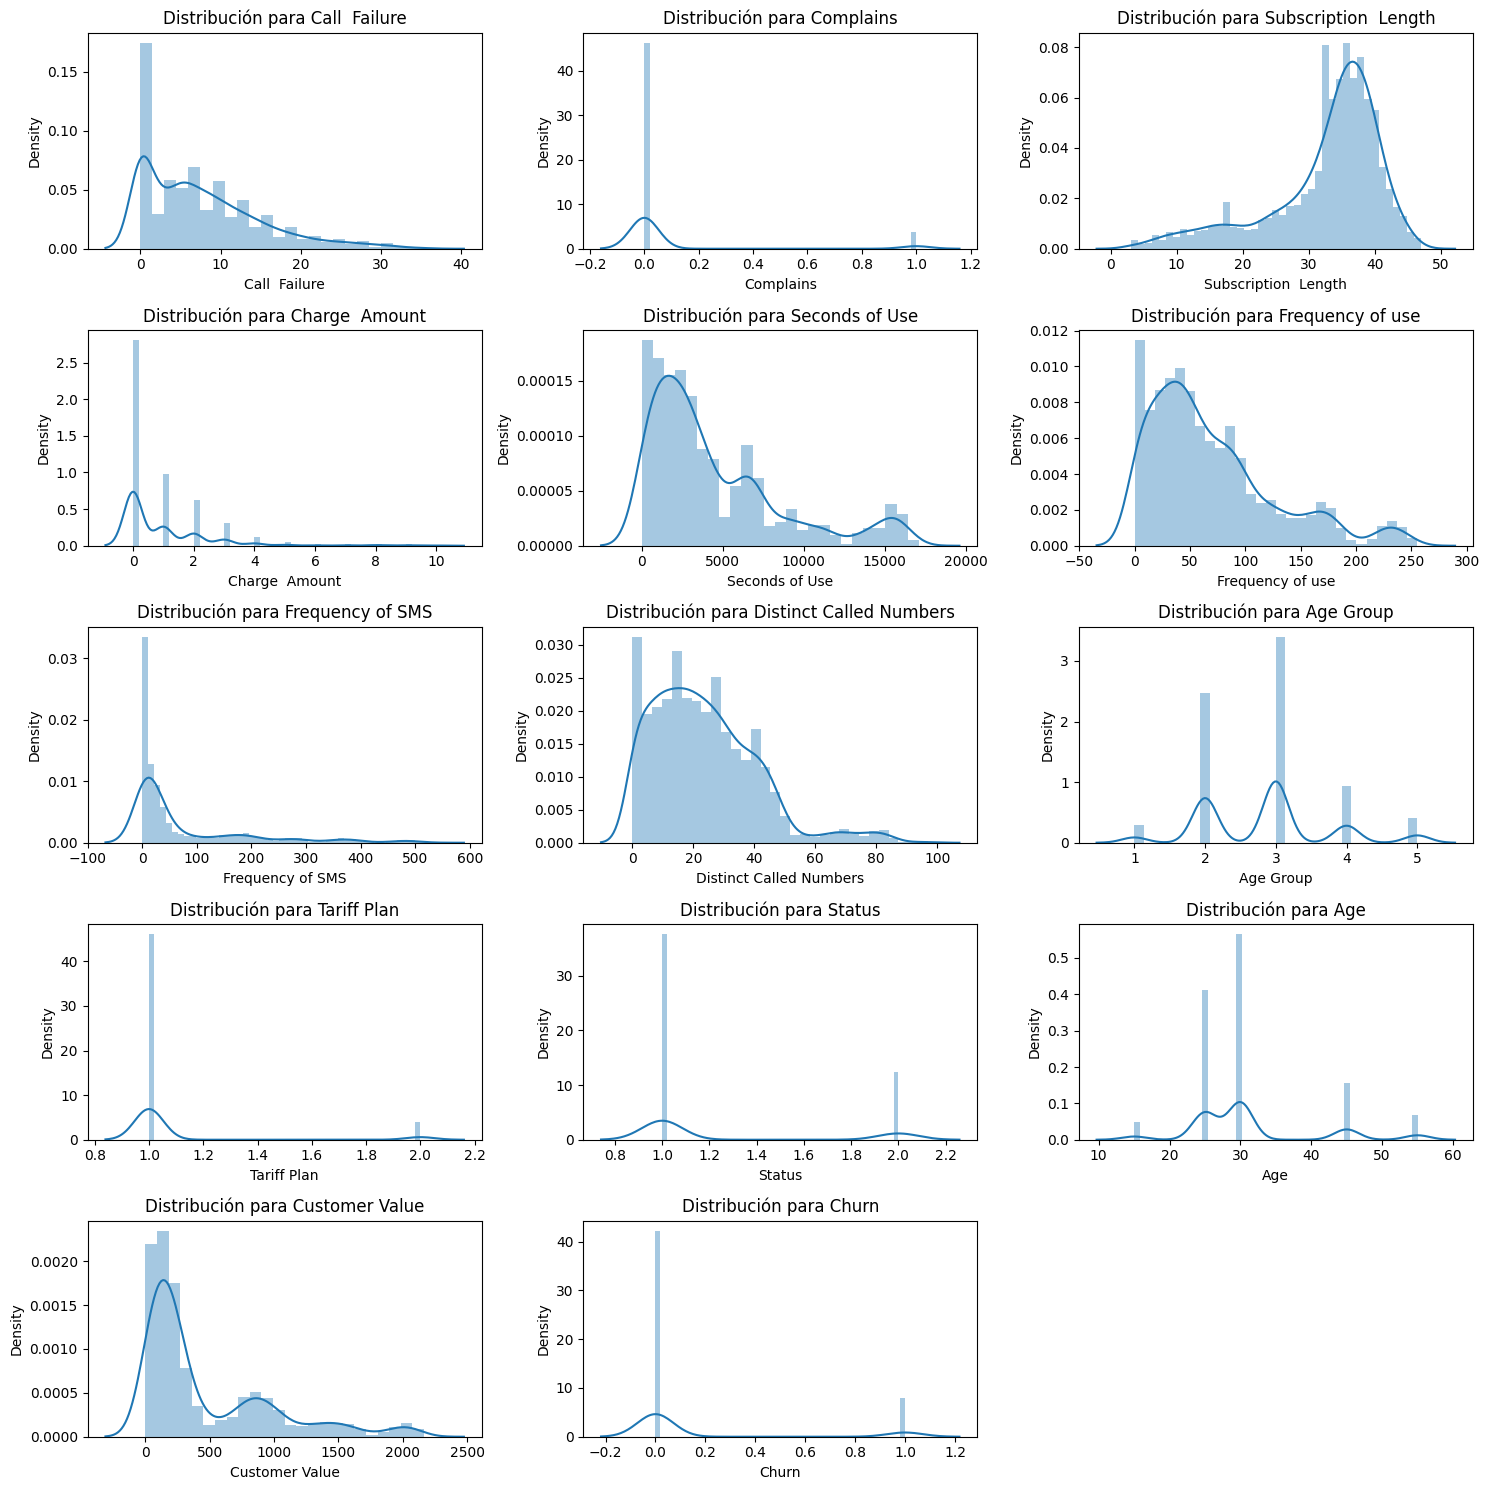

In [ ]:
graficos(calidad_datos(df_inicial), df_inicial, df_inicial.columns)

**Conclusión:** Considerando la información contenida en el diccionario de datos. Analizándo la calidad de los datos y los gráficos que reflejan cómo se distribuyen los datos. Se decide prescindir del atributo **Complains** dado el desbalance entre sus clases y la cantidad de elementos con valor 0 que contiene, el cual representa aproximadamente el 92% del dataset.

In [ ]:
df = df_inicial.drop(['Complains'], axis = 1)

##2. Churn v/s Subscriprtion Length

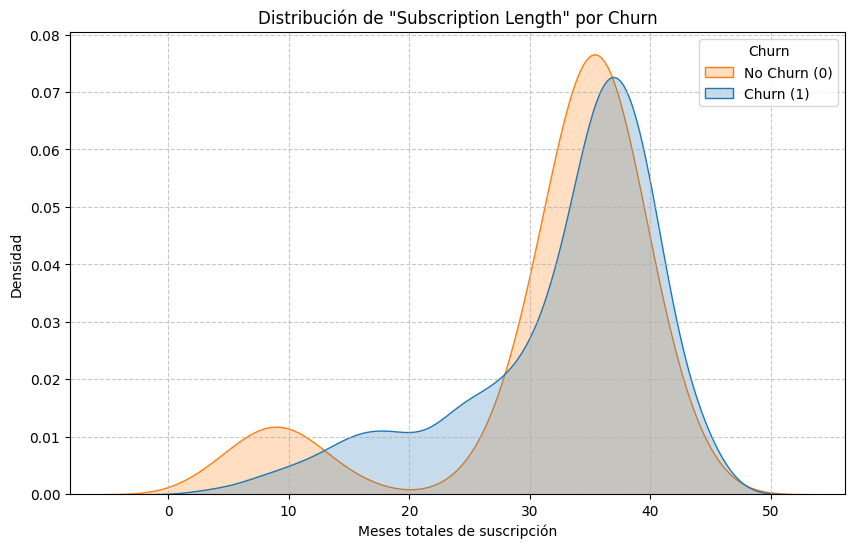

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Subscription  Length', hue='Churn', fill=True, common_norm=False)
plt.title('Distribución de "Subscription Length" por Churn')
plt.xlabel('Meses totales de suscripción')
plt.ylabel('Densidad')
plt.legend(title='Churn', labels=['No Churn (0)', 'Churn (1)'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Conclusión:** Al analizar los primeros 2 años, se observa que los clientes de esta Compañía son más propensos a dejarla entre los 12 y 24 meses después de haber contratado los servicios.

Se oberva que ambas categorías presentan una distribución similar a partir de los 2 años de permanencia.

El análisis del gráfico sugiere  realizar acciones de retención a contar del 10 mes de haber contratado los servicios.



##3. Definición de conjuntos Train y Test.

In [ ]:
X = df.drop(['Churn'], axis = 1)
y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state=42)

##4. Modelo Machine Learning **RandomForest**

In [ ]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [ ]:
RFC = RandomForestClassifier()
RFC.fit(X_train, y_train)


RandomForestClassifier()

In [ ]:
y_pred = RFC.predict(X_test)


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       867
           1       0.88      0.75      0.81       173

    accuracy                           0.94      1040
   macro avg       0.91      0.86      0.89      1040
weighted avg       0.94      0.94      0.94      1040



### Aplicar SMOTE al conjunto de entrenamiento

Aplicamos SMOTE para balancear la clase `Churn` en el conjunto de entrenamiento. Esto ayudará a que el modelo no esté sesgado hacia la clase mayoritaria (no Churn).

In [ ]:
print(f"Forma original de X_train: {X_train.shape}")
print(f"Forma original de y_train: {y_train.shape}")
print(f"Distribución de clases en y_train antes de SMOTE:\n{y_train.value_counts()}")

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"\nForma de X_train después de SMOTE: {X_train_res.shape}")
print(f"Forma de y_train después de SMOTE: {y_train_res.shape}")
print(f"Distribución de clases en y_train después de SMOTE:\n{y_train_res.value_counts()}")

Forma original de X_train: (2110, 12)
Forma original de y_train: (2110,)
Distribución de clases en y_train antes de SMOTE:
Churn
0    1788
1     322
Name: count, dtype: int64

Forma de X_train después de SMOTE: (3576, 12)
Forma de y_train después de SMOTE: (3576,)
Distribución de clases en y_train después de SMOTE:
Churn
0    1788
1    1788
Name: count, dtype: int64


### Importancia de las Características para el Modelo RandomForest (RFC2)

Se vuelve a entrenar el modelo RandomForest, considerando las clases balanceadas mediante SMOTE

In [ ]:
RFC2 = RandomForestClassifier()
RFC2.fit(X_train_res, y_train_res)

RandomForestClassifier()

In [ ]:
y_pred_res = RFC2.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_res))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       867
           1       0.82      0.84      0.83       173

    accuracy                           0.94      1040
   macro avg       0.89      0.90      0.90      1040
weighted avg       0.94      0.94      0.94      1040



,Feature,Importance
0,Status,0.183759
1,Frequency of use,0.155894
2,Subscription Length,0.132815
3,Seconds of Use,0.121253
4,Customer Value,0.087212
5,Distinct Called Numbers,0.086927
6,Frequency of SMS,0.076480


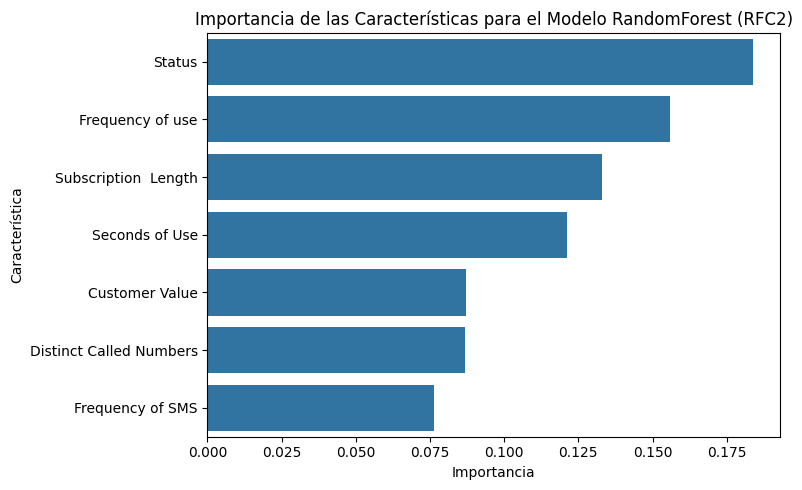

In [ ]:
feature_importances = RFC2.feature_importances_
feature_names = X.columns # Use original column names from X before scaling and SMOTE

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df_sorted = importance_df.sort_values(by='Importance', ascending=False)
importance_df_sorted.reset_index(drop=True, inplace=True)
importance_df_sorted = importance_df_sorted.iloc[0:7,:]
display(importance_df_sorted)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df_sorted)
plt.title('Importancia de las Características para el Modelo RandomForest (RFC2)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

##5.

In [ ]:
X_train_res

array([[ 0.33903589,  0.75818307,  0.04629334, ..., -0.56676918,
        -1.80334489, -0.10573529],
       [-0.62451233,  0.99131718, -0.61818935, ...,  1.7643867 ,
        -0.10969902, -0.83858453],
       [-0.48686258,  0.29191485, -0.61818935, ..., -0.56676918,
        -0.10969902,  0.60611583],
       ...,
       [-1.03746157, -2.80119714, -0.61818935, ..., -0.56676918,
        -0.67424764, -0.76624115],
       [-0.96906547,  0.44709552, -0.50813218, ..., -0.56676918,
         1.58394684, -0.85068984],
       [ 0.2989136 ,  0.79947806, -0.61818935, ...,  1.7643867 ,
        -0.10969902, -0.55198602]])

In [ ]:
y_train_res

,Churn
0,0
1,0
2,0
3,0
4,0
...,...
3571,1
3572,1
3573,1
3574,1


In [ ]:
importance_df_sorted

,Feature,Importance
0,Status,0.183759
1,Frequency of use,0.155894
2,Subscription Length,0.132815
3,Seconds of Use,0.121253
4,Customer Value,0.087212
5,Distinct Called Numbers,0.086927
6,Frequency of SMS,0.076480


In [ ]:
categorias = importance_df_sorted.Feature.tolist()

### 5.1. Filtrar el conjunto de datos con las características más importantes y preparar para el modelo de Red Neuronal

In [ ]:
X_RNA = df[importance_df_sorted.Feature.tolist()]

In [ ]:
X_RNA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Status                   3150 non-null   int64  
 1   Frequency of use         3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Seconds of Use           3150 non-null   int64  
 4   Customer Value           3150 non-null   float64
 5   Distinct Called Numbers  3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 172.4 KB


In [ ]:
y_RNA = y

In [ ]:
X_train_RNA, X_test_RNA, y_train_RNA, y_test_RNA = train_test_split(X_RNA, y_RNA, test_size = 0.33 , random_state = 42 )

In [ ]:
print(y_train_RNA.value_counts())

Churn
0    1788
1     322
Name: count, dtype: int64


In [ ]:
sm = SMOTE(random_state=42)
X_train_RNA_res, y_train_RNA_res = sm.fit_resample(X_train_RNA, y_train_RNA)

In [ ]:
print(y_train_RNA_res.value_counts())

Churn
0    1788
1    1788
Name: count, dtype: int64


In [ ]:
ss = StandardScaler()
X_train_RNA_res_scaled = ss.fit_transform(X_train_RNA_res)

5.2. Ajuste de parámetros manualmente.

In [ ]:
modelo_RNA = Sequential() # clase Sequential: admite agregar capas

# La forma del Input Layer debe coincidir con el número de características de X_train_RNA_res_scaled
modelo_RNA.add(tf.keras.Input(shape = (X_train_RNA_res_scaled.shape[1],)))

modelo_RNA.add(
    Dense(
        units = 50, # Aumentamos las unidades en la capa oculta
        activation = 'tanh',
        use_bias = True
    )
)



modelo_RNA.add(
    Dense(
        units = 1,
        activation = 'sigmoid', # 1 neurona de salida, con activación sigmoid, ideal para clasif. binaria
        use_bias = True
    )
)

In [ ]:
modelo_RNA.compile(optimizer=SGD(learning_rate=0.005), loss='binary_crossentropy', metrics=['accuracy'])
modelo_RNA.fit(X_train_RNA_res_scaled, y_train_RNA_res, verbose=1, epochs=400)

Epoch 1/400
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7055 - loss: 0.6102
Epoch 2/400
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7942 - loss: 0.4991
Epoch 3/400
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8160 - loss: 0.4718
Epoch 4/400
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8140 - loss: 0.4624
Epoch 5/400
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8160 - loss: 0.4582
Epoch 6/400
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8171 - loss: 0.4559
Epoch 7/400
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8166 - loss: 0.4545
Epoch 8/400
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8152 - loss: 0.4535
Epoch 9/400
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8157 - loss: 0.4527
Epoch 10/400
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8152 - loss: 0.4521
Epoch 11/400
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8157 - loss: 0.4516
Epoch 12/400
112/112 ━━━━━━━━━━━━━━━━━━━━

5.3 Evaluación de métricas AUC y reporte de Clasificación

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
AUC-ROC del modelo de Red Neuronal: 0.9112


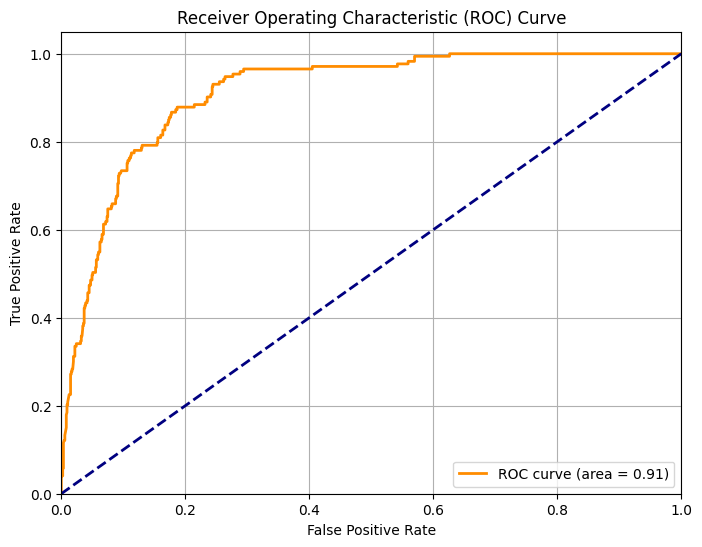

In [ ]:
y_pred_proba = modelo_RNA.predict(ss.transform(X_test_RNA))

# Aplanar y_pred_proba a un array 1D
y_pred_proba_flat = y_pred_proba.flatten()

# Calcular el AUC-ROC
roc_auc = roc_auc_score(y_test_RNA, y_pred_proba_flat)
print(f"AUC-ROC del modelo de Red Neuronal: {roc_auc:.4f}")

# Generar la curva ROC
fpr, tpr, thresholds = roc_curve(y_test_RNA, y_pred_proba_flat)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
# Escalar los datos de prueba usando el mismo StandardScaler ajustado en el entrenamiento
X_test_RNA_scaled = ss.transform(X_test_RNA)

# Obtener las predicciones de probabilidad del modelo
y_pred_proba_test = modelo_RNA.predict(X_test_RNA_scaled)

# Convertir las probabilidades a clases binarias usando el umbral de 0.7
yhat_test = np.where(y_pred_proba_test > 0.7, 1, 0)

# Imprimir el reporte de clasificación
print(classification_report(y_test_RNA, yhat_test))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.96      0.84      0.90       867
           1       0.51      0.80      0.62       173

    accuracy                           0.84      1040
   macro avg       0.73      0.82      0.76      1040
weighted avg       0.88      0.84      0.85      1040



### Evaluación de las métricas del modelo de Red Neuronal

El modelo de Red Neuronal ha sido evaluado utilizando el conjunto de prueba (`X_test_RNA`, `y_test_RNA`). Los resultados son los siguientes:

*   **AUC-ROC**: El Área Bajo la Curva ROC (AUC-ROC) obtenida es **0.9112**.
    *   Este valor indica una excelente capacidad del modelo para distinguir entre las clases positivas y negativas. Un AUC-ROC cercano a 1 sugiere que el modelo tiene una alta probabilidad de clasificar correctamente un ejemplo elegido aleatoriamente como positivo y uno elegido aleatoriamente como negativo.

*   **Reporte de Clasificación (con umbral de 0.7)**:
    ```
                  precision    recall  f1-score   support

               0       0.96      0.84      0.90       867
               1       0.51      0.80      0.62       173

        accuracy                           0.84      1040
       macro avg       0.73      0.82      0.76      1040
    weighted avg       0.88      0.84      0.85      1040
    ```

    **Interpretación del Reporte de Clasificación (con umbral de 0.7):**

    *   **Clase 0 (No Churn):**
        *   **Precision (0.96):** De todos los clientes que el modelo predijo como 'No Churn', el 96% realmente no hicieron churn. Esto es muy bueno, indica que hay pocos falsos positivos para la clase 0.
        *   **Recall (0.84):** De todos los clientes que realmente 'No Churn', el modelo identificó correctamente el 84%. Esto significa que un 16% de los clientes que no hicieron churn fueron incorrectamente clasificados como churn (falsos positivos de la clase 1).
        *   **F1-Score (0.90):** Un valor alto que indica un buen balance entre precisión y recall para la clase mayoritaria.

    *   **Clase 1 (Churn):**
        *   **Precision (0.51):** De todos los clientes que el modelo predijo que harían churn, solo el 51% realmente lo hicieron. Esto es un valor bajo. Significa que casi la mitad de las veces que el modelo dice que un cliente va a irse, se equivoca (son falsos positivos para la clase 1). Esto podría llevar a invertir recursos de retención en clientes que no lo necesitan.
        *   **Recall (0.80):** De todos los clientes que realmente hicieron 'Churn', el modelo identificó correctamente el 80%. Este es un buen valor, lo que indica que el modelo es bastante efectivo detectando a los clientes que van a renunciar, aunque deja escapar a un 20% de ellos (falsos negativos).
        *   **F1-Score (0.62):** Este valor es moderado y refleja el bajo valor de precisión. A pesar del buen recall, el modelo tiene muchas predicciones de churn que no se materializan.

    *   **Accuracy (0.84):** La precisión general del modelo es del 84%.

**Conclusión con el umbral de 0.7:**

Al usar un umbral de 0.7, el modelo se vuelve más conservador al predecir 'Churn'. Esto tiene el efecto de:

*   **Mantener un alto Recall para la clase 1 (Churn):** El modelo sigue siendo bueno identificando a la mayoría de los clientes que sí harán churn (80%).
*   **Reducir (o mantener bajo) la Precision para la clase 1 (Churn):** La precisión para la clase 'Churn' sigue siendo baja (0.51). Esto es crítico porque significa que, por cada cliente que predice correctamente como 'churn', hay casi uno que predice incorrectamente. Si el costo de las acciones de retención es alto, esto puede ser problemático.
*   **Mejorar la Precision para la clase 0 (No Churn):** El modelo es muy bueno prediciendo quienes *no* harán churn (0.96).

En un escenario de predicción de churn, la importancia relativa de la precisión y el recall para la clase 'Churn' depende de los costos y beneficios de cada tipo de error. Si el objetivo es identificar a la mayor cantidad posible de churners reales para intervenir (sin importar si algunos no iban a irse), un recall alto es preferible. Si, por el contrario, las acciones de retención son muy costosas y se quiere evitar intervenir en clientes que se quedarían de todos modos, entonces la precisión para la clase 'Churn' debería ser más alta. El valor de AUC-ROC de 0.9112 sigue indicando que el modelo tiene una buena capacidad de discriminación general.